In [1]:
# pip install xgboost shap

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay, confusion_matrix, ConfusionMatrixDisplay
)

import xgboost as xgb
import shap

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

PALETTE = {'no': '#5A7FC4', 'yes': '#E8593C'}

# SECTION 1 — LOAD DATA

In [2]:
import pandas as pd

df = pd.read_csv(
    '/kaggle/input/datasets/abihasamar/bank-marketing-dataset/bank-full.csv',
    sep=';',
    quotechar='"'
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [3]:
print("Shape:", df.shape)
print("\nClass distribution:")
print(df['y'].value_counts())

Shape: (45211, 17)

Class distribution:
y
no     39922
yes     5289
Name: count, dtype: int64


# SECTION 2 — EXPLORATORY DATA ANALYSIS

## 2.1 Basic info

In [5]:

print("\nMissing values:\n", df.isnull().sum())
print("\nDescribe (numeric):\n", df.describe().T)
 


Missing values:
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Describe (numeric):
             count         mean          std     min    25%    50%     75%  \
age       45211.0    40.936210    10.618762    18.0   33.0   39.0    48.0   
balance   45211.0  1362.272058  3044.765829 -8019.0   72.0  448.0  1428.0   
day       45211.0    15.806419     8.322476     1.0    8.0   16.0    21.0   
duration  45211.0   258.163080   257.527812     0.0  103.0  180.0   319.0   
campaign  45211.0     2.763841     3.098021     1.0    1.0    2.0     3.0   
pdays     45211.0    40.197828   100.128746    -1.0   -1.0   -1.0    -1.0   
previous  45211.0     0.580323     2.303441     0.0    0.0    0.0     0.0   

               max  
age           95.0  
balance   102127.0  
day         

## 2.2 Distribution of Target Column

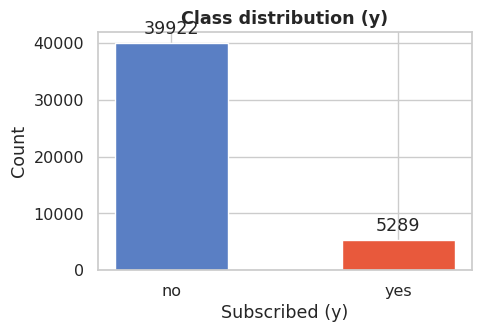

In [6]:
fig, ax = plt.subplots(figsize=(5, 3.5))
counts = df['y'].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=[PALETTE['no'], PALETTE['yes']], width=0.5, edgecolor='white')
ax.bar_label(bars, fmt='%d', padding=4)
ax.set_title('Class distribution (y)', fontweight='bold')
ax.set_xlabel('Subscribed (y)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=150)
plt.show()
 

Imbalanced data!

## 2.3 Numeric distributions by target

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


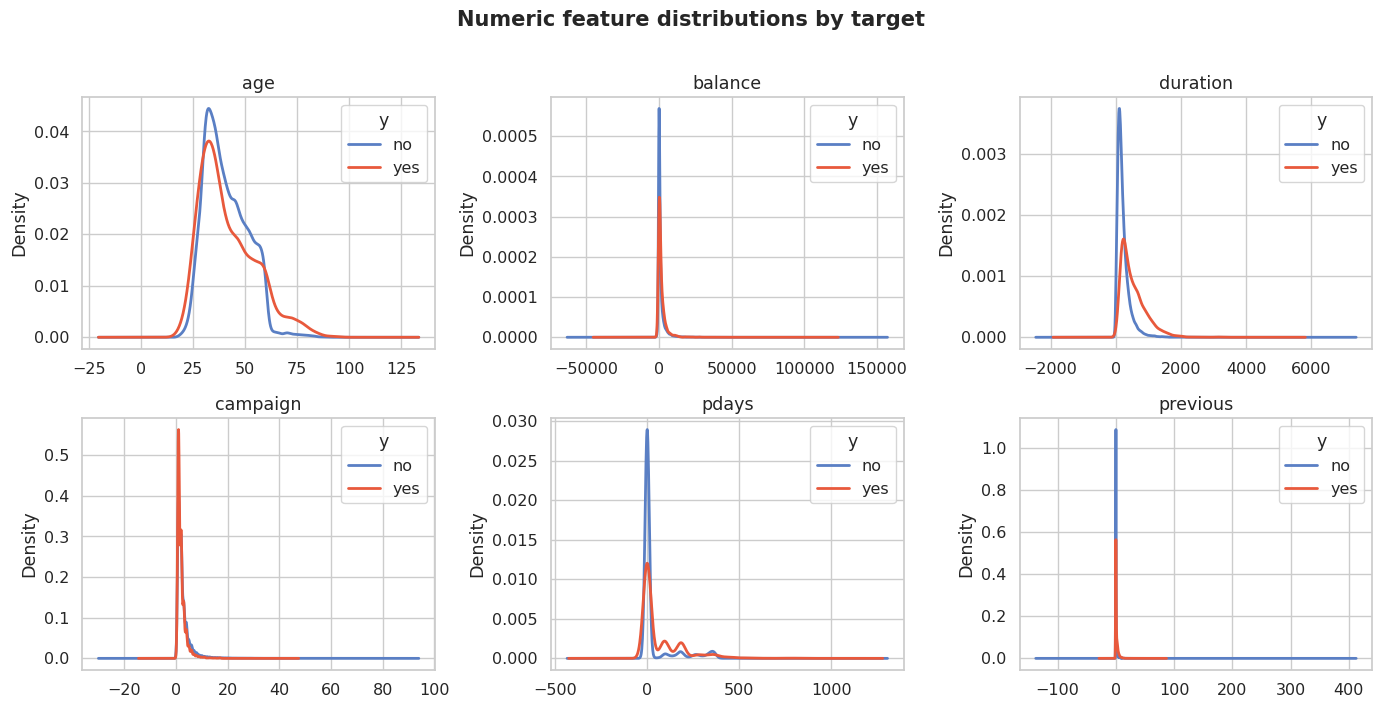

In [7]:
num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
 
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), num_cols):
    for label, grp in df.groupby('y')[col]:
        grp.plot(kind='kde', ax=ax, label=label,
                 color=PALETTE[label], linewidth=2)
    ax.set_title(col)
    ax.legend(title='y')
fig.suptitle('Numeric feature distributions by target', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_numeric_distributions.png', dpi=150)
plt.show()

## 2.4 Categorical subscription rates

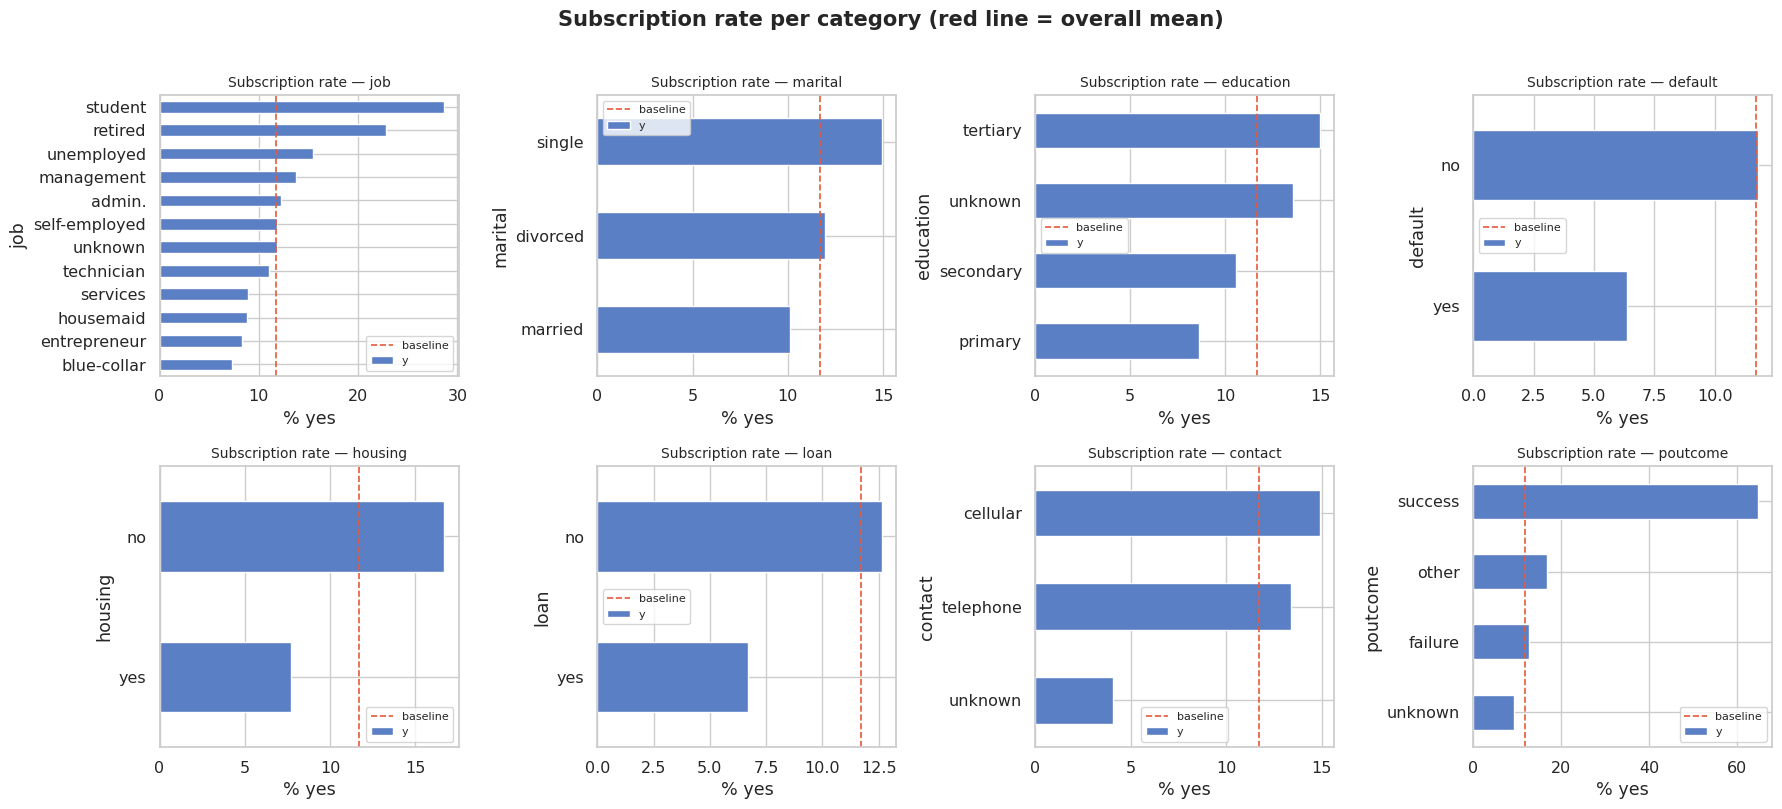

In [8]:
cat_cols = ['job', 'marital', 'education', 'default',
            'housing', 'loan', 'contact', 'poutcome']
 
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    rates = (df.groupby(col)['y']
               .apply(lambda x: (x == 'yes').mean() * 100)
               .sort_values(ascending=True))
    rates.plot(kind='barh', ax=ax, color='#5A7FC4', edgecolor='white')
    ax.set_title(f'Subscription rate — {col}', fontsize=10)
    ax.set_xlabel('% yes')
    ax.axvline(x=(df['y'] == 'yes').mean() * 100,
               color='#E8593C', linestyle='--', linewidth=1.2, label='baseline')
    ax.legend(fontsize=8)
plt.suptitle('Subscription rate per category (red line = overall mean)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('03_categorical_subscription_rates.png', dpi=150)
plt.show()
 

## 2.5 Correlation heatmap (numeric only)

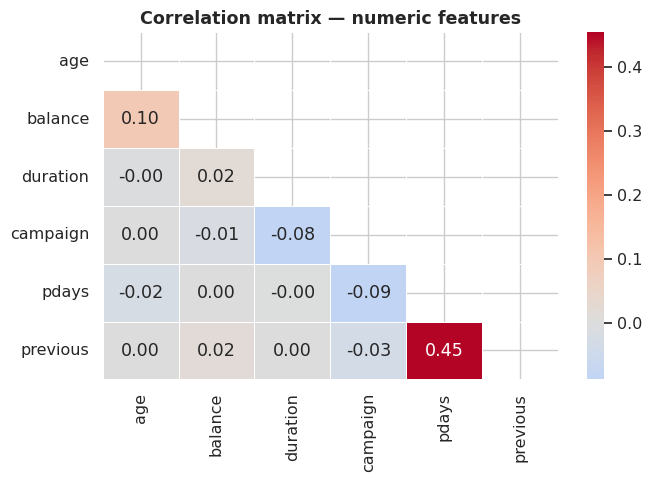

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation matrix — numeric features', fontweight='bold')
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', dpi=150)
plt.show()

# SECTION 3 — FEATURE ENGINEERING

In [12]:
df_fe = df.copy()

##  3.1 Target encode

In [13]:
df_fe['y_bin'] = (df_fe['y'] == 'yes').astype(int)

## 3.2  was_contacted_before: pdays == -1 means never contacted

In [25]:
df_fe['was_contacted_before'] = (df_fe['pdays'] != -1).astype(int)


## 3.3 pdays_clean: replace -1 sentinel with 999 (large numeric value)

In [14]:
df_fe['pdays_clean'] = df_fe['pdays'].replace(-1, 999)

## 3.4 high_balance: above median

In [15]:
# EDA showed near-identical raw balance distributions for both classes —
# the binary split captures the signal without the extreme outlier noise
df_fe['high_balance'] = (df_fe['balance'] > df_fe['balance'].median()).astype(int)

 ## 3.5 has_any_loan: either housing or personal loan

In [17]:
# Both housing (8% vs 16%) and loan (7% vs 12%) individually reduce conversion.
# Combining them into one flag keeps the model lean.
df_fe['has_any_loan'] = (
    ((df_fe['housing'] == 'yes') | (df_fe['loan'] == 'yes')).astype(int)
)

## 3.6 previous_success: poutcome was success

In [19]:
# EDA: success category converts at ~65% vs 11% baseline — strongest single signal
df_fe['previous_success'] = (df_fe['poutcome'] == 'success').astype(int)

## 3.7 log_duration: log-transform duration (heavily right-skewed) 

In [20]:
# NOTE: duration is excluded as raw feature — you can't know call duration
# before making the call (data leakage). log_duration is kept as a proxy
# that compresses extreme outliers and is used only for retrospective analysis.
df_fe['log_duration'] = np.log1p(df_fe['duration'])
 

## 3.8 job_tier: ordinal job risk tier from EDA

In [21]:
 #student (~28%) and retired (~22%) convert 2x baseline
# blue-collar, entrepreneur, housemaid convert ~0.5x baseline
job_tier_map = {
    'student':      2,   # high converters (~28%)
    'retired':      2,   # high converters (~22%)
    'unemployed':   1,   # near baseline
    'management':   1,
    'admin.':       1,
    'self-employed':1,
    'unknown':      1,
    'technician':   1,
    'services':     0,   # below baseline
    'housemaid':    0,
    'entrepreneur': 0,
    'blue-collar':  0,
}
df_fe['job_tier'] = df_fe['job'].map(job_tier_map).fillna(1)

## 3.9 education_ordinal

In [22]:
# EDA shows clean monotonic pattern: tertiary > secondary > primary
# Ordinal encoding preserves this gradient better than one-hot
 
edu_order_map = {
    'primary':   0,
    'secondary': 1,
    'unknown':   1,   # treat unknown as middle ground
    'tertiary':  2,
}
df_fe['education_ordinal'] = df_fe['education'].map(edu_order_map).fillna(1)

# 3.10 contact_known

In [23]:
# unknown contact → ~5% conversion vs 11-14% for cellular/telephone
df_fe['contact_known'] = (df_fe['contact'] != 'unknown').astype(int)

## 3.11 campaign_capped

In [26]:
# EDA showed almost all variation is in 1-5 range; beyond that is pure noise
df_fe['campaign_capped'] = df_fe['campaign'].clip(upper=5)
 
print("\nEngineered features added:")
new_feats = ['was_contacted_before', 'pdays_clean', 'high_balance', 'has_any_loan',
             'previous_success', 'log_duration', 'job_tier', 'education_ordinal',
             'contact_known', 'campaign_capped']
print(df_fe[new_feats].head(3))


Engineered features added:
   was_contacted_before  pdays_clean  high_balance  has_any_loan  \
0                     0          999             1             1   
1                     0          999             0             1   
2                     0          999             0             1   

   previous_success  log_duration  job_tier  education_ordinal  contact_known  \
0                 0      5.568345         1                  2              0   
1                 0      5.023881         1                  1              0   
2                 0      4.343805         0                  1              0   

   campaign_capped  
0                1  
1                1  
2                1  


# SECTION 4: PREPROCESSING PIPELINE

In [30]:
FEATURES = [
    # original numeric
    'age', 'day', 'pdays_clean', 'previous',
    # engineered numeric
    'log_duration', 'was_contacted_before', 'high_balance',
    'has_any_loan', 'previous_success',
    'campaign_capped', 'job_tier', 'education_ordinal', 'contact_known',
    # categorical (remaining)
    'marital', 'default', 'housing', 'loan', 'poutcome',
]
TARGET = 'y_bin'
X = df_fe[FEATURES]
y = df_fe[TARGET]

## 4.2 Train / test split 

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.3f}  |  Test: {y_test.mean():.3f}")
 


Train: (36168, 18)  |  Test: (9043, 18)
Train positive rate: 0.117  |  Test: 0.117


In [32]:
numeric_features = [
    'age', 'day', 'pdays_clean', 'previous',
    'log_duration', 'was_contacted_before', 'high_balance',
    'has_any_loan', 'previous_success',
    'campaign_capped', 'job_tier', 'education_ordinal', 'contact_known',
]
categorical_features = [
    'marital', 'default', 'housing', 'loan', 'poutcome',
]
 
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
     categorical_features)
])
 

## SECTION 5 Logistic Regression

In [33]:
lr_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(
        class_weight='balanced',   # handles imbalance
        max_iter=1000,
        random_state=42
    ))
])
 
# Cross-validation (ROC-AUC)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_cv_scores = cross_val_score(lr_pipeline, X_train, y_train,
                                cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"\n[LR] CV ROC-AUC: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")
 
# Fit and evaluate on test set
lr_pipeline.fit(X_train, y_train)
lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]
lr_pred  = lr_pipeline.predict(X_test)
 
print(f"[LR] Test ROC-AUC : {roc_auc_score(y_test, lr_proba):.4f}")
print(f"[LR] Test F1 (yes): {f1_score(y_test, lr_pred):.4f}")
print("\nClassification Report (LR):")
print(classification_report(y_test, lr_pred, target_names=['no', 'yes']))
 
 


[LR] CV ROC-AUC: 0.8925 ± 0.0026
[LR] Test ROC-AUC : 0.8912
[LR] Test F1 (yes): 0.4969

Classification Report (LR):
              precision    recall  f1-score   support

          no       0.97      0.80      0.88      7985
         yes       0.36      0.83      0.50      1058

    accuracy                           0.80      9043
   macro avg       0.66      0.81      0.69      9043
weighted avg       0.90      0.80      0.83      9043

